<center><h2>EXAMEN SUR MACHINE DE DATA SCIENCE (A7 2024-2025)</h2></center>

Epreuve sans documents (hors Campus et référence aux bibliothèques). Tous objets connectés interdits.

L'objectif de cette évaluation est de valider votre capacité à réaliser des traitements standards sur des données pour : 
- manipuler un ensemble de données (gérer des valeurs manquantes, des valeurs aberrantes) ;
- analyser et visualiser les variables de cet ensemble ;
- réduire la dimension de l'espace de travail et mettre en évidence des variables susceptibles d'être pertinentes pour une application donnée ;
- mettre en forme les données pour construire des modèles de régression ou de classification (dans un contexte supervisé et non supervisé) ;
- évaluer et interpréter les modèles.

L'épreuve se déroule sur jupyter notebook

Vous disposez des différents documents vus en cours sur le campus https://campus.eseo.fr/ ainsi que les références aux bibliothèques. Tout autre document est interdit.

**Vous devez impérativement renommer votre script (.ipynb) avec le nommage suivant~: NOM_PRENOM__DS.ipynb** 
    
**Votre programme doit s'exécuter sans erreur et afficher les figures demandées.**

**Certaines questions amènent à commenter votre réponse. Pour autant, le code développé pour répondre à la question doit impérativement être présent ; le commentaire seul n'est pas considéré comme une réponse acceptable.**

**Vous ne devez pas changer le nom de la base de données.**

<center><h3>Description de la base de données</h3></center>

L'objectif est de prédire si un vol sera en retard (`retard`). Les variables à notre disposition sont :
- `heure_depart` : heure de départ prévue (0 à 23) ;
- `duree_vol`: durée prévue du vol (en minutes) ;
- `nb_vols_jour` : nombre total de vols ce jour-là depuis l'aéroport ;
- `retards_7j_moy` : retard moyen des vols de la compagnie sur les 7 derniers jours (en minutes);
- `compagnie` : nom de la compagnie ;
- `meteo_depart` : météo prévue à l'heure du décollage ;
- `retard` : **variable qualitative à prédire** : le vol a du retard (1) ou le vol est à l'heure (0).


In [3]:
# Bibliothèque
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix


In [4]:
# Charger les données
df = pd.read_csv('data_exam_A7.csv', sep=',')

In [5]:
df

,heure_depart,duree_vol,nb_vols_jour,retards_7j_moy,compagnie,meteo_depart,retard
0,8.3,114.8,110.0,9.0,FlyY,Bonne,0
1,5.4,124.7,112.0,12.0,SkyZ,Bonne,0
2,9.4,135.7,105.0,12.0,FlyY,Mauvaise,0
3,1.1,105.0,144.0,19.0,FlyY,Bonne,0
4,9.1,134.5,94.0,26.0,AirX,Bonne,0
...,...,...,...,...,...,...,...
1995,8.9,123.0,136.0,0.0,FlyY,Bonne,0
1996,2.8,117.4,123.0,15.0,SkyZ,Bonne,0
1997,7.1,74.8,146.0,20.0,AirX,Bonne,0
1998,3.7,129.6,98.0,14.0,AirX,Bonne,0


**1) Analyser la distribution de la variable cibe `retard` en fonction de `meteo_depart`. Commenter.** \[1,5 point\]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   heure_depart    2000 non-null   float64
 1   duree_vol       2000 non-null   float64
 2   nb_vols_jour    2000 non-null   float64
 3   retards_7j_moy  2000 non-null   float64
 4   compagnie       2000 non-null   object 
 5   meteo_depart    2000 non-null   object 
 6   retard          2000 non-null   int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 109.5+ KB
None
(2000, 7)
       heure_depart    duree_vol  nb_vols_jour  retards_7j_moy       retard
count   2000.000000  2000.000000   2000.000000     2000.000000  2000.000000
mean       9.006050   131.832100    121.444500       18.157500     0.206000
std        6.314541    40.896765     33.559261       10.396573     0.404532
min      -15.000000    30.000000     50.000000        0.000000     0.000000
25%        4.800000   104.3000

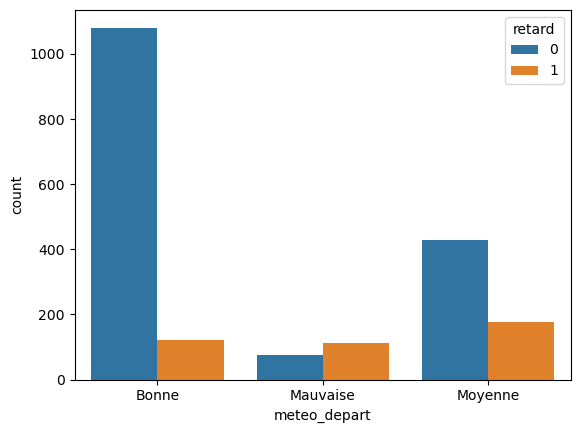

In [8]:
# développer votre code pour répondre à la question
print(df.info())
print(df.shape)
print(df.describe())
print(pd.crosstab(df["meteo_depart"],df["retard"],normalize ='index'))
sns.countplot(data=df , x='meteo_depart',hue='retard')
plt.show()

**2) Les retards sont-ils spécifiques à une compagnie ? Commenter.** \[1,5 point\]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   heure_depart    2000 non-null   float64
 1   duree_vol       2000 non-null   float64
 2   nb_vols_jour    2000 non-null   float64
 3   retards_7j_moy  2000 non-null   float64
 4   compagnie       2000 non-null   object 
 5   meteo_depart    2000 non-null   object 
 6   retard          2000 non-null   int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 109.5+ KB
None
(2000, 7)
       heure_depart    duree_vol  nb_vols_jour  retards_7j_moy       retard
count   2000.000000  2000.000000   2000.000000     2000.000000  2000.000000
mean       9.006050   131.832100    121.444500       18.157500     0.206000
std        6.314541    40.896765     33.559261       10.396573     0.404532
min      -15.000000    30.000000     50.000000        0.000000     0.000000
25%        4.800000   104.3000

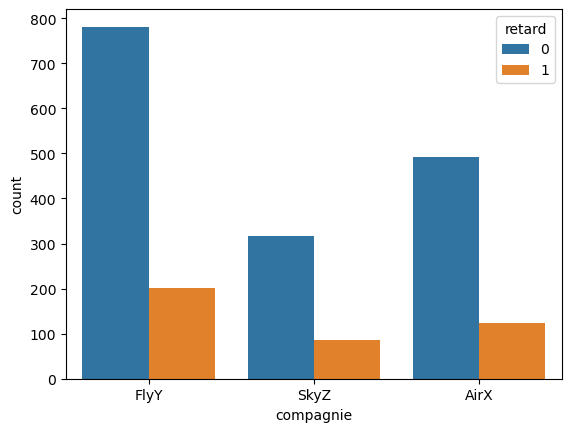

In [9]:
# développer votre code pour répondre à la question

print(df.info())
print(df.shape)
print(df.describe())
print(pd.crosstab(df["compagnie"],df["retard"],normalize ='index'))
sns.countplot(data=df , x='compagnie',hue='retard')
plt.show()

**3) Analyser l'ensemble de données pour détecter d'éventuelles valeurs manquantes, aberrantes ou incohérentes, puis effectuer un nettoyage approprié. Décriver dans le cadre (ci-dessous) les éléments détectés et expliquer votre traitement.** \[2 points\]

In [9]:
# développer votre code pour répondre à la question
df.describe()
#print( "heure de départ hors de la plage normazle ",df[(df['heure_depart'] < 0)].drop() | (df['heure_depart'] > 23))
#print("Durer négative",df[(df["duree_vol"] < 0)])
#quant = ['heure_depart','duree_vol','nb_vols_jour','retards_7j_moy','retard']
#qual = ['meteo_depart','compagnie']
#for c in quant : df[c] = df[c].fillna(df[c].median())
#for c in qual : df[c] = df[c].fillna(df[c].mod())
#df = df.drop_duplicates()
df.drop(df[df['heure_depart'] < 0].index)

,heure_depart,duree_vol,nb_vols_jour,retards_7j_moy,compagnie,meteo_depart,retard
0,8.3,114.8,110.0,9.0,FlyY,Bonne,0
1,5.4,124.7,112.0,12.0,SkyZ,Bonne,0
2,9.4,135.7,105.0,12.0,FlyY,Mauvaise,0
3,1.1,105.0,144.0,19.0,FlyY,Bonne,0
4,9.1,134.5,94.0,26.0,AirX,Bonne,0
...,...,...,...,...,...,...,...
1995,8.9,123.0,136.0,0.0,FlyY,Bonne,0
1996,2.8,117.4,123.0,15.0,SkyZ,Bonne,0
1997,7.1,74.8,146.0,20.0,AirX,Bonne,0
1998,3.7,129.6,98.0,14.0,AirX,Bonne,0


**4) Visualiser la capacité de chacune des variables quantitatives à discriminer la variable cible `retard`. Choisir la variable qui vous semble la plus pertinente pour prédire la variable cible `retard`. Justifier ce choix** \[3 points\]

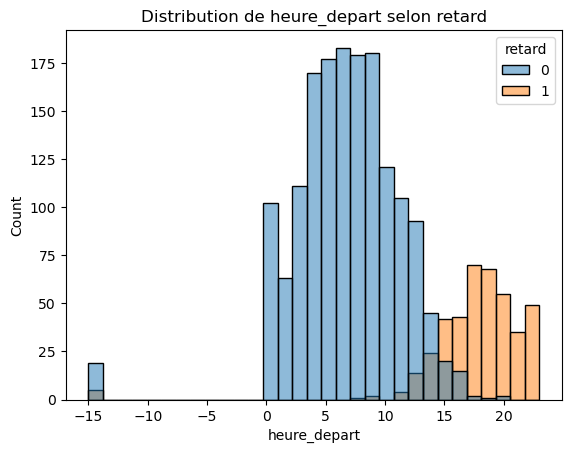

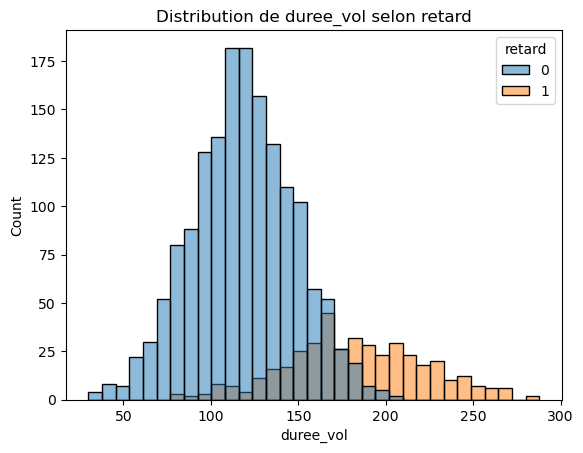

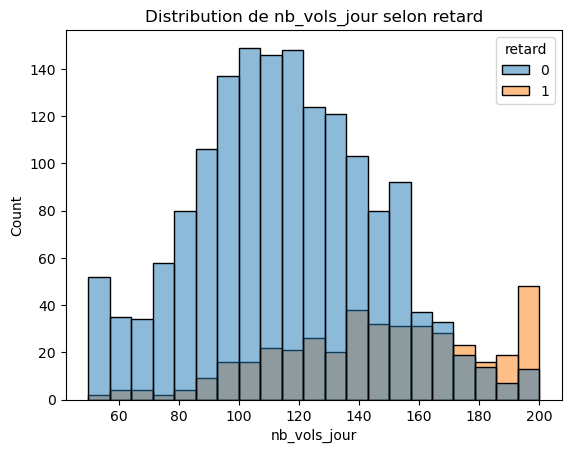

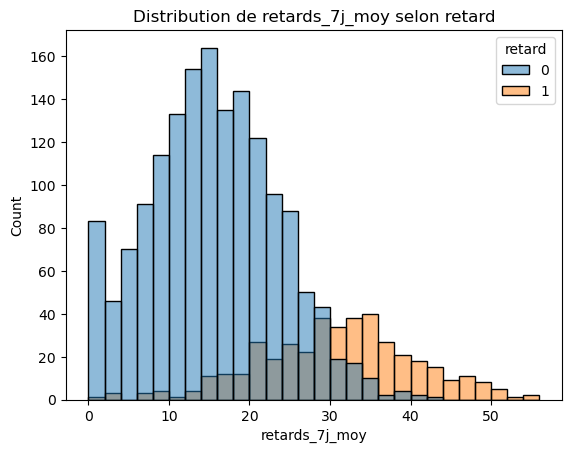

In [11]:
import seaborn as sns


# Ou en version boucle pour toutes les variables de 'quant' (sauf 'retard' si elle est dedans)
for var in ['heure_depart','duree_vol','nb_vols_jour','retards_7j_moy']:
    sns.histplot(data=df, x=var, hue='retard', bins=30, alpha=0.6, stat='density', common_norm=False)
    plt.title(f'Distribution de {var} selon retard')
    plt.show()

**5) Préparer les données de manière à optimiser la création et l'évaluation des modèles de classification. Justifier les traitements appliqués sur les données.** \[2 points]

In [14]:
X=df[['heure_depart']]
y=df['retard']

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state= 42,stratify = y)
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

**6) Construire un modèle de classification sur la base de la variable que vous avez choisie et évaluer ses performances. Commenter la valeur de l'indicateur qui vous a permis d'évaluer votre modèle.** \[3 points]

ValueError: n_components=2 must be between 0 and min(n_samples, n_features)=1 with svd_solver='covariance_eigh'

In [17]:
# développer votre code pour répondre à la question
x_train_h = x_train_s[:,[0]]
x_test_h = x_test_s[:,[0]]

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_h,y_train)
y_predict = knn.predict(x_test_h)

print(confusion_matrix(y_test, y_predict))
print(classification_report(y_test,y_predict))

[[464  12]
 [ 21 103]]
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       476
           1       0.90      0.83      0.86       124

    accuracy                           0.94       600
   macro avg       0.93      0.90      0.91       600
weighted avg       0.94      0.94      0.94       600



**7) Visualiser la distribution des échantillons d'apprentissage en fonction de leur classe (`retard`) dans un nouvel espace formé par les deux premières composantes principales obtenues par l'analyse en composantes principales. Donner le pourcentage de la variance des données initiales expliquée dans ces deux composantes principales et interpréter cette valeur.** [3 points]

In [28]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Reprendre toutes les colonnes
x_train_s = scaler.fit_transform(x_train)   # x_train doit contenir toutes les features

pca = PCA(n_components=2)
x_train_pca = pca.fit_transform(x_train_s)


# Variance expliquée
var_exp = pca.explained_variance_ratio_
print("Variance PC1 :", var_exp[0])
print("Variance PC2 :", var_exp[1])
print("Variance totale :", var_exp.sum())

# Visualisation
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=x_train_pca[:,0],
    y=x_train_pca[:,1],
    hue=y_train,
    palette="viridis"
)
plt.xlabel(f"PC1 ({var_exp[0]*100:.2f} %)")
plt.ylabel(f"PC2 ({var_exp[1]*100:.2f} %)")
plt.title("Projection PCA des échantillons d'apprentissage")
plt.show()


ValueError: n_components=2 must be between 0 and min(n_samples, n_features)=1 with svd_solver='covariance_eigh'

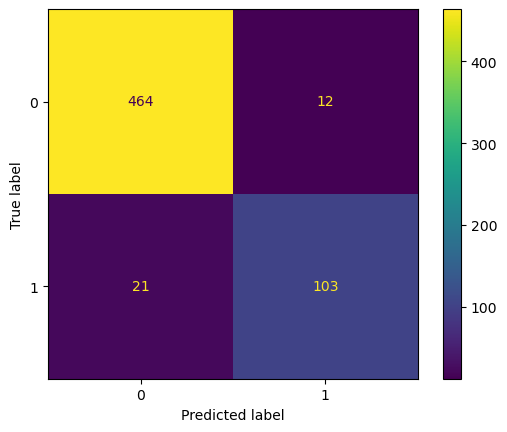

In [18]:
# développer votre code pour répondre à la question
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
# Matrice de confusion
cm = confusion_matrix(y_test, y_predict)
# Affichage
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


**8) Construire un nouveau modèle de classification dans le nouvel espace défini par les deux premières composantes principales et évaluer ses performances. Comparer les performances avec le classifieur précédent et commenter.** [2 points]

In [10]:
# développer votre code pour répondre à la question


**9) Quelle est la probabilité que ce vol soit en retard ?** \[2 points\]


In [65]:
# définition de l'échantillon à tester
df_test = pd.DataFrame([{
    'heure_depart': 14,
    'duree_vol': 110,
    'nb_vols_jour': 65,
    'retards_7j_moy': 27,
    'compagnie': 'AirX',
    'meteo_depart': 'Moyenne',
    'retard':np.nan
}])
df_test.head()


P_retard = scaler.transform(df_test[quant])[:,[0]]
proba = knn.predict_proba(P_retard)[0][1]
print("Probabiliter de tretard",proba)

Probabiliter de tretard 0.2
